# はじめに

このノートでは、PyTorch Geometricを利用してグラフニューラルネットワークを構築することを目指す。最初はPyTorchの基礎からはじめ、グラフニューラルネットワーク、PyTorch Geometricと内容を進めていく。

今回は、PyTorch Geometricを使って競艇の「展開」を捉えるための特徴量を作る、ということを都合の良いダミーデータを使って実践する。このノートの内容はあくまでも実際に利用する埋め込みのイメージを理解するためのものなので、このまま利用しているわけではない。そして、学習中なので、やっている内容が要件にマッチせず、頓珍漢なことをしているかもしてない。

下記はグラフニューラルネットワークを理解するための参考サイト。

- [グラフニューラルネットワーク | 佐藤 竜馬](https://www.amazon.co.jp/%E3%82%B0%E3%83%A9%E3%83%95%E3%83%8B%E3%83%A5%E3%83%BC%E3%83%A9%E3%83%AB%E3%83%8D%E3%83%83%E3%83%88%E3%83%AF%E3%83%BC%E3%82%AF-%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%97%E3%83%AD%E3%83%95%E3%82%A7%E3%83%83%E3%82%B7%E3%83%A7%E3%83%8A%E3%83%AB%E3%82%B7%E3%83%AA%E3%83%BC%E3%82%BA-%E4%BD%90%E8%97%A4-%E7%AB%9C%E9%A6%AC/dp/4065347823)
- [グラフ深層学習のすゝめ。 - YouTube](https://www.youtube.com/watch?v=7rgXi3Xp6NI)
- [GCN — グラフ道場](https://yuya-s.github.io/GraphDojo/01GCN.html)
- [Tutorial 6: Basics of Graph Neural Networks](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html)
- [Static and Dynamic Attention: Implications for Graph Neural Networks](https://medium.com/data-science/static-and-dynamic-attention-implications-for-graph-neural-networks-eda0d9d7b60a)
- [CS224W | Home](https://web.stanford.edu/class/cs224w/index.html)
- [nn.labml.ai/ja/graphs](https://nn.labml.ai/#:~:text=%E2%9C%A8%20Graph%20Neural%20Networks)
- [Understanding Convolutions on Graphs](https://distill.pub/2021/understanding-gnns/)
- [A Gentle Introduction to Graph Neural Networks](https://distill.pub/2021/gnn-intro/)

## ダミーデータ生成

まずは都合の良いデータでうまく展開特徴量を作成することができそうか試す。生成するデータの特徴は下記の通り。

| pattern | 展開   | 特徴          |
| ------- | ---- | ----------- |
| nige    | イン逃げ | 1号艇が強くSTも速い |
| makuri  | まくり  | 3・4号艇のSTが速い |
| konsen  | 混戦   | 全艇ほぼ同等      |


In [ ]:
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from torch_geometric.data import Data
from torch_geometric.data import Batch
from torch_geometric.nn import GATv2Conv
from torch_geometric.loader import DataLoader


pl.Config.set_tbl_rows(-1)
rng = np.random.default_rng(1)


def sample_winner(pattern):

    if pattern == "nige":
        return rng.choice([1, 2, 3], p=[0.7, 0.2, 0.1])
    elif pattern == "makuri":
        return rng.choice([3, 4, 1], p=[0.4, 0.4, 0.2])
    else:
        return rng.integers(1, 7)


def make_race(pattern: str, race_id: str):

    lanes = np.arange(1, 7)
    if pattern == "nige":
        st = np.array([0.12, 0.14, 0.17, 0.18, 0.19, 0.20])
        rating = np.array([80, 70, 60, 58, 55, 54])
    elif pattern == "makuri":
        st = np.array([0.19, 0.17, 0.11, 0.12, 0.18, 0.19])
        rating = np.array([80, 68, 72, 70, 55, 54])
    else:
        st = np.array([0.15, 0.15, 0.14, 0.16, 0.15, 0.16])
        rating = np.array([68, 67, 66, 67, 65, 66])

    # ノイズ
    st = st + rng.normal(0, 0.004, size=6)
    rating = rating + rng.normal(0, 1.2, size=6)

    # 展開スコア（説明用）
    score = 0.7 * rating - 120 * st

    # 着順生成
    order = np.argsort(-score)
    ranks = np.empty(6, dtype=int)
    ranks[order] = np.arange(1, 7)
    winner = sample_winner(pattern)

    rows = []

    for i in range(6):
        rows.append(
            {
                "RaceId": race_id,
                "pattern": pattern,
                "Teiban": int(lanes[i]),
                "StartTime_5races": float(st[i]),
                "glicko2_rating_waku": float(rating[i]),
                "score": float(score[i]),
                "Ranking": int(ranks[i]),
                "winner_true": int(winner),
            }
        )

    return rows


rows = []
patterns = ["nige", "makuri", "konsen"]

for p in patterns:
    for i in range(1000):
        race_id = f"{p}_{i:03d}"
        rows.extend(make_race(p, race_id))

df = pl.DataFrame(rows)

データの頭とお尻を確認しておく。

In [2]:
df.head(12)

RaceId,pattern,Teiban,StartTime_5races,glicko2_rating_waku,score,Ranking,winner_true
str,str,i64,f64,f64,f64,i64,i64
"""nige_000""","""nige""",1,0.121382,79.355656,40.983079,1,1
"""nige_000""","""nige""",2,0.143286,70.697342,32.293762,2,1
"""nige_000""","""nige""",3,0.171322,60.437487,21.747631,3,1
"""nige_000""","""nige""",4,0.174787,58.352959,19.872587,4,1
"""nige_000""","""nige""",5,0.193621,55.034107,15.289304,5,1
"""nige_000""","""nige""",6,0.201785,54.656056,14.044979,6,1
"""nige_001""","""nige""",1,0.119348,79.691369,41.462155,1,2
"""nige_001""","""nige""",2,0.138072,70.009771,32.438257,2,2
"""nige_001""","""nige""",3,0.172395,59.669277,21.081047,3,2


In [3]:
df.tail(12)

RaceId,pattern,Teiban,StartTime_5races,glicko2_rating_waku,score,Ranking,winner_true
str,str,i64,f64,f64,f64,i64,i64
"""konsen_998""","""konsen""",1,0.150929,67.90888,29.424792,3,1
"""konsen_998""","""konsen""",2,0.146716,65.310286,28.111267,5,1
"""konsen_998""","""konsen""",3,0.135786,68.33507,31.540173,1,1
"""konsen_998""","""konsen""",4,0.154616,68.887297,29.66713,2,1
"""konsen_998""","""konsen""",5,0.148047,66.049625,28.469126,4,1
"""konsen_998""","""konsen""",6,0.164886,62.794425,24.169737,6,1
"""konsen_999""","""konsen""",1,0.158271,67.066947,27.954337,6,5
"""konsen_999""","""konsen""",2,0.151214,69.870537,30.763718,1,5
"""konsen_999""","""konsen""",3,0.143577,67.688004,30.152422,2,5


展開の違いを直感的に表現できそうか、生成されたデータを確認してみる。`gap`は横の艇と差を計算しており、`score`の大小に応じて着順が連動するようにデータを生成しているので、逃げの場合は内側の艇が大きく、まくりの場合は外側の艇が大きくなっている。混戦の場合はどの艇もあまり差がない。このことからも生成時に用いた特徴量を使うことで「展開」のような埋め込み特徴量を作れそうではある。

In [ ]:
score_df = (
    df.group_by("RaceId")
    .agg(
        pl.col("score").sort(descending=True).alias("sorted_score"),
        pl.first("pattern").alias("pattern"),
    )
    .with_columns(
        [pl.col("sorted_score").list.get(i).alias(f"s{i+1}") for i in range(6)]
    )
    .with_columns(
        [(pl.col(f"s{i}") - pl.col(f"s{i+1}")).alias(f"gap{i}") for i in range(1, 6)]
    )
)
gap_summary = score_df.group_by("pattern").agg(
    pl.mean("gap1"),
    pl.mean("gap2"),
    pl.mean("gap3"),
    pl.mean("gap4"),
    pl.mean("gap5"),
)

gap_summary

pattern,gap1,gap2,gap3,gap4,gap5
str,f64,f64,f64,f64,f64
"""konsen""",0.807855,0.660216,0.7033,0.679058,0.828109
"""makuri""",2.488065,1.5636,5.883727,10.269614,1.981976
"""nige""",9.429604,10.506922,2.663548,3.244974,2.05939


## PyGのための準備

`build_edge_index`はGNNのグラフ構造（どのノードがどのノードとつながるか、艇同士の相互作用）を作る関数。ここでは完全グラフを利用する。

In [5]:
def build_edge_index(num_nodes=6):

    src = []
    dst = []

    for i in range(num_nodes):
        for j in range(num_nodes):

            if i != j:
                src.append(i)
                dst.append(j)

    edge_index = torch.tensor([src, dst], dtype=torch.long)

    return edge_index

In [6]:
build_edge_index().shape, build_edge_index()

(torch.Size([2, 30]),
 tensor([[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
          4, 5, 5, 5, 5, 5],
         [1, 2, 3, 4, 5, 0, 2, 3, 4, 5, 0, 1, 3, 4, 5, 0, 1, 2, 4, 5, 0, 1, 2, 3,
          5, 0, 1, 2, 3, 4]]))

`build_edge_attr`は GNNのエッジ特徴量（edge feature）を作る関数。`edge_index`が、単純なつながりを表現しているのに対し、`build_edge_attr`は2艇の関係がどのくらい違うかを表現する。ここでは「枠」「スタートタイム」「レーティング」で作成している。エッジが30なので、ここでも同じエッジの数×特徴量の数分エッジ特徴量が作られる。

In [ ]:
def build_edge_attr(race_df):

    lanes = race_df["Teiban"].to_numpy()
    st = race_df["StartTime_5races"].to_numpy()
    rating = race_df["glicko2_rating_waku"].to_numpy()

    edge_attr = []

    for i in range(6):
        for j in range(6):

            if i == j:
                continue

            lane_diff = abs(lanes[i] - lanes[j])
            st_diff = abs(st[i] - st[j])
            rating_diff = abs(rating[i] - rating[j])

            edge_attr.append([lane_diff, st_diff, rating_diff])

    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return edge_attr

1レース取り出して、出力をみておく。このあとの`GATv2`で、$α_{ij}​=Attention(h_{i}​,h_{j}​,e_{ij}​)$として、艇$i$が艇$j$をどれくらい意識するかを、コース差、スタートタイム差、レーティング差をもとに決めることになる。

In [8]:
build_edge_attr(df.head(6)).shape, build_edge_attr(df.head(6))

(torch.Size([30, 3]),
 tensor([[1.0000e+00, 2.1904e-02, 8.6583e+00],
         [2.0000e+00, 4.9939e-02, 1.8918e+01],
         [3.0000e+00, 5.3405e-02, 2.1003e+01],
         [4.0000e+00, 7.2239e-02, 2.4322e+01],
         [5.0000e+00, 8.0403e-02, 2.4700e+01],
         [1.0000e+00, 2.1904e-02, 8.6583e+00],
         [1.0000e+00, 2.8035e-02, 1.0260e+01],
         [2.0000e+00, 3.1501e-02, 1.2344e+01],
         [3.0000e+00, 5.0335e-02, 1.5663e+01],
         [4.0000e+00, 5.8499e-02, 1.6041e+01],
         [2.0000e+00, 4.9939e-02, 1.8918e+01],
         [1.0000e+00, 2.8035e-02, 1.0260e+01],
         [1.0000e+00, 3.4656e-03, 2.0845e+00],
         [2.0000e+00, 2.2300e-02, 5.4034e+00],
         [3.0000e+00, 3.0464e-02, 5.7814e+00],
         [3.0000e+00, 5.3405e-02, 2.1003e+01],
         [2.0000e+00, 3.1501e-02, 1.2344e+01],
         [1.0000e+00, 3.4656e-03, 2.0845e+00],
         [1.0000e+00, 1.8834e-02, 3.3189e+00],
         [2.0000e+00, 2.6998e-02, 3.6969e+00],
         [4.0000e+00, 7.2239e-02, 2.43

`build_node_feature`は、GNNのノード特徴量（node feature）を作る関数。データフレームなので、GNNが扱えるようにテンソルに変換している。

In [ ]:
def build_node_feature(race_df):

    x = race_df.select(["StartTime_5races", "glicko2_rating_waku"]).to_numpy()
    x = torch.tensor(x, dtype=torch.float)

    return x

In [10]:
build_node_feature(df.head(6)).shape, build_node_feature(df.head(6))

(torch.Size([6, 2]),
 tensor([[ 0.1214, 79.3557],
         [ 0.1433, 70.6973],
         [ 0.1713, 60.4375],
         [ 0.1748, 58.3530],
         [ 0.1936, 55.0341],
         [ 0.2018, 54.6561]]))

`build_rank_label`は、着順をラベルとして作成する関数。データフレームなので、GNNが扱えるようにテンソルに変換している。

In [11]:
def build_rank_label(race_df):

    ranks = race_df["Ranking"].to_numpy()
    ranks = torch.tensor(ranks, dtype=torch.long)

    return ranks

In [12]:
build_rank_label(df.head(6)).shape, build_rank_label(df.head(6)), df.head(6)

(torch.Size([6]),
 tensor([1, 2, 3, 4, 5, 6]),
 shape: (6, 8)
 ┌──────────┬─────────┬────────┬────────────────┬───────────────┬───────────┬─────────┬─────────────┐
 │ RaceId   ┆ pattern ┆ Teiban ┆ StartTime_5rac ┆ glicko2_ratin ┆ score     ┆ Ranking ┆ winner_true │
 │ ---      ┆ ---     ┆ ---    ┆ es             ┆ g_waku        ┆ ---       ┆ ---     ┆ ---         │
 │ str      ┆ str     ┆ i64    ┆ ---            ┆ ---           ┆ f64       ┆ i64     ┆ i64         │
 │          ┆         ┆        ┆ f64            ┆ f64           ┆           ┆         ┆             │
 ╞══════════╪═════════╪════════╪════════════════╪═══════════════╪═══════════╪═════════╪═════════════╡
 │ nige_000 ┆ nige    ┆ 1      ┆ 0.121382       ┆ 79.355656     ┆ 40.983079 ┆ 1       ┆ 1           │
 │ nige_000 ┆ nige    ┆ 2      ┆ 0.143286       ┆ 70.697342     ┆ 32.293762 ┆ 2       ┆ 1           │
 │ nige_000 ┆ nige    ┆ 3      ┆ 0.171322       ┆ 60.437487     ┆ 21.747631 ┆ 3       ┆ 1           │
 │ nige_000 ┆ nige  

`build_graph`は、は 1レースのデータを「グラフ」に変換する関数。ここまでで作成してきた、ノード特徴量、エッジインデックス、エッジ特徴量、着順ラベルをまとめてPyGのDataオブジェクトを作成する。

In [ ]:
def build_graph(race_df):

    race_df = race_df.sort("Teiban")

    x = build_node_feature(race_df)
    edge_index = build_edge_index()
    edge_attr = build_edge_attr(race_df)
    ranks = build_rank_label(race_df)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, ranks=ranks)
    # レースごとに識別できるように1つの値を取り出す
    data.race_id = race_df["RaceId"][0]
    data.pattern = race_df["pattern"][0]

    return data

In [14]:
build_graph(df.head(6))

Data(x=[6, 2], edge_index=[2, 30], edge_attr=[30, 3], ranks=[6], race_id='nige_000', pattern='nige')

ここまでの関数を使えば、レースごとの値をGNNが使用できる形に整うので、あとはレース数の数分、ループして1つにまとめる。生成されるサイズは`(1000レース * 3種類 * 6艇) // 6レースごと`となる。

In [15]:
graphs = []

for race_id, g in df.group_by("RaceId", maintain_order=True):

    graph = build_graph(g)
    graphs.append(graph)

print(len(graphs))

3000


## PyGで学習

今回は、GATv2layerを2回通すモデルになっている。各艇が、アテンション(`edge_attr`)を利用しながら、他艇の情報を見て、自分の表現を更新する。
`z`は各艇の特徴ベクトルで、艇能力 + 他艇の影響や相互作用を含んだもので「レース全体を見たあとの艇の表現」と解釈できる。

$$
x \in \mathbb{R}^{6×2} \rightarrow h \in \mathbb{R}^{16×6} \rightarrow z \in \mathbb{R}^{6×8}
$$

例えば`z`が下記のような感じであれば、8次元の値はそれぞれに、人間は理解できないものの、学習後にはたとえば内部的に「内有利さ、外の伸び圧、混戦っぽさ、、、、」のようなものを表している可能性がある。まさに展開に必要な各艇の相互作用を埋め込んだものになっている。

```python
z =
[
 [ 1.20,  0.30, -0.10,  0.80,  0.20, -0.50,  0.10,  0.90],   # 1号艇
 [ 0.95,  0.28, -0.05,  0.65,  0.18, -0.42,  0.08,  0.70],   # 2号艇
 [ 0.40,  0.55,  0.20,  0.10,  0.35,  0.15,  0.50,  0.25],   # 3号艇
 [ 0.30,  0.48,  0.25,  0.05,  0.38,  0.22,  0.58,  0.20],   # 4号艇
 [ 0.10,  0.40,  0.35, -0.05,  0.45,  0.30,  0.62,  0.10],   # 5号艇
 [ 0.05,  0.35,  0.42, -0.10,  0.50,  0.38,  0.70,  0.05],   # 6号艇
]
↓
mean_z = [1列目の平均、2列目の平均、3列目の平均、4列目の平均、5列目の平均、6列目の平均、7列目の平均、8列目の平均]
max_z = [1列目の最大値、2列目の最大値、3列目の最大値、4列目の最大値、5列目の最大値、6列目の最大値、7列目の最大値、8列目の最大値]
```

このように`z`は各艇ごとに展開の要素を持っている訳ではあるが、どの艇が一番勝ちやすいかはまだわからない。そこで、大きいほど上位に来やすいというルールをもとに艇$i$の勝ちやすさスコアを計算する。

$$
z \in \mathbb{R}^{6×8} \rightarrow s \in \mathbb{R}^{6×1} 
$$

これを計算するために、`self.score_head = nn.Linear(embed_dim, 1)`で8次元を1次元に写す。中身は$s_{i} = w^T z_{i} + b$の線形変換で、今回のレースにおける勝ちやすさを表現する値を作る。

`mean_z`は各艇の展開のような表現をレース全体の表現としてまとめ直している。LightGBMなどでは1レースごとの値として保持させる予定なので。つまり、このレースの平均的な雰囲気を`mean_z`は持ち、その1列目が仮に「イン有利」を表現しているのであれば、その成分の平均が高いなら、展開としてはイン有利と言えるかもしれない。`max_z, sorted_scores, score_gaps`も処理内容としてはこの通り。

`sorted_scores`は少しややこしく処理自体は並び替えではあるが、

```python
scores        = [1.4, 3.2, 1.2, 2.7, 1.9, 1.0]
↓
並び替え
↓
sorted_scores = [3.2, 2.7, 1.9, 1.4, 1.2, 1.0]
```

例えば上の例と関係ないが、`[3.5, 1.8, 1.7, 1.5, 1.2, 1.1]`と並び替わるのと、混戦で`[2.0, 1.9, 1.8, 1.7, 1.6, 1.5]`と並び替わるとでは、その後の`score_gaps = sorted_scores[:-1] - sorted_scores[1:]`の隣同士の差の表現が変わってくる。最初の例だと`[1.7, 0.1, 0.2, 0.3, 0.1]`な感じで1艇が強いことがわかる。つまり、`score_gaps`はレースの荒れやすさみたいなものを表現する。

あとはレースごとの表現をまとめたベクトルをつなげる。

```python
mean_z        = 8 -> 平均的なレース度合い。レースAの平均が大きいとき、強い艇が多い。逆にレースBでは、平均が小さいと、平均して弱い艇が多い。
max_z         = 8 -> 最強艇の強さ。レースAで強い艇が5という数字を持ち、レースBでは最も強くで2の場合、抜けてる選手がいるかどうかを示す。
scores        = 6 -> 各艇の勝ちやすさ
sorted_scores = 6 -> 強さ構造、強さの形を表す。艇番は関係なく、混戦になるのか、1艇だけ抜けている1強戦なのか、3艇くらいが強いのかを示す。
score_gaps    = 5 -> 強さの差。スコアで強いもの順にお並び替えたときに、差がどのくらいあるか。
-----------------
合計          = 32次元
```

仮に上記のように埋め込みがされていても、1カラムだけを見てもわからないのでは、という疑問あるかもしれない。これはその通りで、複数の何らかを表現するカラムをLigthGBMに学習させ、学習時の分岐をもとに、展開なるものを学習してもらうことになる。なので、このembeddingは各レースの選手特徴量ではなく、レース構造の展開特徴量として機能するはず。

In [ ]:
class BoatRaceGNN(nn.Module):

    def __init__(
        self,
        node_dim=2,  # ノード特徴量数
        edge_dim=3,  # edge feature数
        hidden_dim=16,  # 中間層のノード数
        embed_dim=8,  # 出力層のノード数
    ):
        super().__init__()

        # -------------------------
        # GATv2 layers
        # -------------------------
        self.gat1 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)  # (2, 16, 3)
        self.gat2 = GATv2Conv(hidden_dim, embed_dim, edge_dim=edge_dim)  # (16, 8, 3)
        self.score_head = nn.Linear(embed_dim, 1)  # (8, 1)

    # -------------------------------------------------
    # forward
    # -------------------------------------------------

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr

        h = self.gat1(x, edge_index, edge_attr)
        h = F.relu(h)
        z = self.gat2(h, edge_index, edge_attr)  # (6*B, E)
        # print(f"Shape of z(Before view): {z.shape}")
        scores = self.score_head(z).squeeze(-1)  # (6*B,)
        # print(f"Shape of scores(Before view): {scores.shape}")
        B = data.num_graphs
        E = z.size(1)

        z = z.view(B, 6, E)  # (B, 6, E)
        # print(f"Shape of z(After view): {z.shape}")

        scores = scores.view(B, 6)  # (B, 6)
        # print(f"Shape of scores(After view): {scores.shape}")

        mean_z = z.mean(dim=1)  # (B, E)
        # print(f"Shape of mean_z(After view): {mean_z.shape}")
        max_z = z.max(dim=1).values  # (B, E)
        # print(f"Shape of max_z(After view): {max_z.shape}")
        sorted_scores, _ = torch.sort(scores, dim=1, descending=True)  # (B, 6)
        # print(f"Shape of sorted_scores(After view): {sorted_scores.shape}")
        score_gaps = sorted_scores[:, :-1] - sorted_scores[:, 1:]  # (B, 5)
        # print(f"Shape of score_gaps(After view): {score_gaps.shape}")

        race_emb = torch.cat(
            [mean_z, max_z, scores, sorted_scores, score_gaps], dim=1
        )  # (B, 2E + 6 + 6 + 5)

        return z, scores, race_emb


# Shape of z(Before view): torch.Size([768, 8])
# Shape of scores(Before view): torch.Size([768])
# Shape of z(After view): torch.Size([128, 6, 8])
# Shape of scores(After view): torch.Size([128, 6])
# Shape of mean_z(After view): torch.Size([128, 8])
# Shape of max_z(After view): torch.Size([128, 8])
# Shape of sorted_scores(After view): torch.Size([128, 6])
# Shape of score_gaps(After view): torch.Size([128, 5])

PyGでグラフデータをミニバッチで読み込むための仕組みを作る。ここでのGNNの学習は 1レースずつではなく、複数レースをまとめて処理するので、`DataLoader`でミニバッチを作成する。

In [17]:
loader = DataLoader(graphs, batch_size=128, shuffle=False)
model = BoatRaceGNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

損失はplackett_luce_lossを利用する。`scores`から順位確率を作り、正しい順位ほど`loss`が小さくなるようにする。`score`から正しい順位の確率を作れるように学習する。用語の整理をしておく。

| 要素             | 意味      |
| -------------- | ------- |
| scores         | 艇番ごとの強さ |
| ranks          | 艇番ごとの順位 |
| order          | 順位順の艇番  |
| ordered_scores | 順位順のスコア |

まずはこのように艇番ごとの`score`と`ranks`の関係がる。

| 艇番 | score | 順位 |ranks|
| :--: | :-----: | :--: |:--: |
| 1  | 2.3   | 2着 |1 |
| 2  | 1.5   | 3着 |2 |
| 3  | 3.1   | 1着 |0 |
| 4  | 0.8   | 4着 |3 |
| 5  | 0.7   | 5着 |4 |
| 6  | 0.6   | 6着 |5 |

そこから、`ranks`を下に`order`を求め、`order`で順位とスコアを並び替える。

|order|艇番|順位 |ordered_score|
| :--: |:--: |:--: |:--: |
|2|3号艇|1着 |3.1  |
|0|1号艇|2着 |2.3 |
|1|2号艇|3着 |1.5 |
|3|4号艇|4着 |0.8 |
|4|5号艇|5着 | 0.7|
|5|6号艇|6着 |0.6 |

あとはplackett_luceの尤度を小さくするようにグラフニューラルネットワークの重みを調整する。

$$
L = \sum_{k=1}^{n}\left(\log \sum_{j=k}^{n} e^{s_{\pi_j}} - s_{\pi_k}\right)
$$

説明のために枠番通り、1着が1号艇、2着が2号艇、3着が3号艇とすると下記の表のようになる。順位があっても自信の強さという表現がただしいかはさておき、確率の大小により、`loss`も変わってくる。


| ケース  | scores          | 意味         |  loss |
| ---- | --------------- | ---------- | ----: |
| ケース1 | (3.0, 2.0, 1.0) | 正しい順位を強く表す | 0.721 |
| ケース2 | (1.2, 1.1, 1.0) | 正しいが差が小さい  | 1.646 |
| ケース3 | (1.0, 2.0, 3.0) | 順位が逆       | 3.721 |

Plackett–Luce loss は正しい順位になっているだけではなく、正しい順位をどれだけはっきり出しているかを見ている損失といえる。

In [18]:
def plackett_luce_loss(scores, ranks):

    order = torch.argsort(ranks, dim=1)
    ordered_scores = scores.gather(1, order)
    n = ordered_scores.size(1)
    loss = 0

    for k in range(n):
        denom = torch.logsumexp(ordered_scores[:, k:], dim=1)
        loss += denom - ordered_scores[:, k]

    return loss.mean()

あとはこれまでの内容の通りで、学習を回してグラフニューラルネットワークからEmbeddingを得る。

In [ ]:
epochs = 501

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        z, scores, race_emb = model(batch)
        scores = scores.view(batch.num_graphs, 6)
        ranks = batch.ranks.view(batch.num_graphs, 6)
        loss = plackett_luce_loss(scores, ranks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 50 == 0:
        print(f"epoch {epoch:02d} loss {total_loss:.4f}")

epoch 00 loss 155.3034
epoch 50 loss 59.4409
epoch 100 loss 57.2046
epoch 150 loss 54.8607
epoch 200 loss 52.4865
epoch 250 loss 51.5395
epoch 300 loss 54.3166
epoch 350 loss 48.4261
epoch 400 loss 47.8053
epoch 450 loss 47.6205
epoch 500 loss 47.8996


## 

graphsの1つ目を取り出すとこのような感じ

In [20]:
with torch.no_grad():
    # 例として
    g = graphs[0]
    # DataLoader(batch_size=...)が渡すDataにはbatch属性があるので、それを付与する
    g = g.to(device)
    g_batch = Batch.from_data_list([g]).to(device)  # 複数グラフのバッチとしてラップ

    z, scores, race_emb = model(g_batch)

print(z.shape)
print(z)
print(scores.shape)
print(scores)
print(race_emb.shape)
print(race_emb)

torch.Size([1, 6, 8])
tensor([[[  49.3614,   79.5080,   94.2943,   22.3525,  -67.0921, -388.9673,
          -137.7932,  -84.6721],
         [  48.4760,   78.1080,   92.6122,   21.8793,  -65.9221, -382.5652,
          -135.4769,  -83.1298],
         [  46.8094,   75.4754,   89.4465,   20.9914,  -63.7174, -370.5179,
          -131.1152,  -80.2264],
         [  46.1886,   74.4940,   88.2671,   20.6599,  -62.8966, -366.0289,
          -129.4906,  -79.1449],
         [  45.6363,   73.6215,   87.2180,   20.3655,  -62.1661, -362.0366,
          -128.0454,  -78.1828],
         [  45.4220,   73.2835,   86.8110,   20.2520,  -61.8820, -360.4880,
          -127.4840,  -77.8093]]])
torch.Size([1, 6])
tensor([[1460.1602, 1435.1121, 1387.9685, 1370.4043, 1354.7820, 1348.7200]])
torch.Size([1, 33])
tensor([[  46.9823,   75.7484,   89.7749,   21.0834,  -63.9460, -371.7673,
         -131.5676,  -80.5275,   49.3614,   79.5080,   94.2943,   22.3525,
          -61.8820, -360.4880, -127.4840,  -77.8093, 146

GNNが競艇の展開を区別するEmbeddingを学習できているか確認する。グラフごとにembeddingである`race_emb`を取得する。これは、レースの展開を表現する埋め込みである。次元が高いので、PCAよりもで2次元に圧縮して可視化する。

可視化された結果をみると、PC1は展開のタイプを表現し、PC2は展開の優位度が表現されているかもしれない。つまり、PC1はそのレースが逃げやすいのか、混戦になるのか、まくられるのか、PC2は1号艇がどれだけ有利なのか。

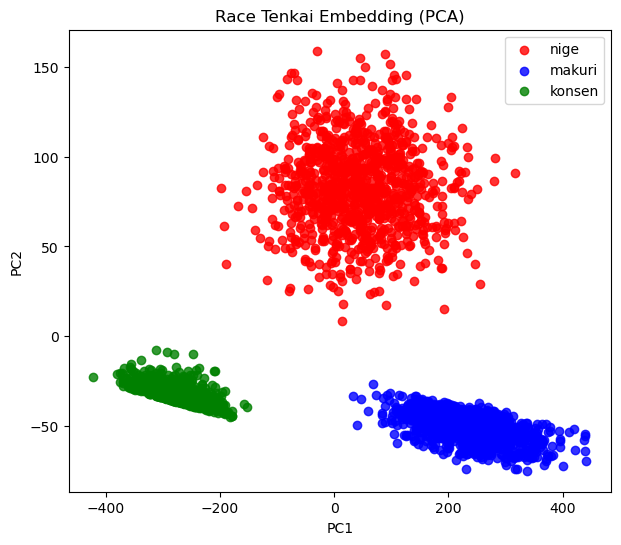

In [ ]:
# -----------------------
# embedding取得
# -----------------------
model.eval()
race_embs = []
labels = []

for g in graphs:
    g = g.to(device)
    # 単一グラフをBatchとしてラップしてmodelに渡す
    g_batch = Batch.from_data_list([g]).to(device)
    with torch.no_grad():
        _, _, race_emb = model(g_batch)  # g -> g_batch
    race_embs.append(race_emb.cpu().numpy())
    # patternラベル
    rid = g.race_id
    if "nige" in rid:
        labels.append("nige")
    elif "makuri" in rid:
        labels.append("makuri")
    else:
        labels.append("konsen")

# Embeddingをつみあげる
X = np.vstack(race_embs)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)

# -----------------------
# 可視化
# -----------------------

colors = {"nige": "red", "makuri": "blue", "konsen": "green"}

plt.figure(figsize=(7, 6))

for label in ["nige", "makuri", "konsen"]:
    idx = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(Z[idx, 0], Z[idx, 1], c=colors[label], label=label, alpha=0.8)

plt.legend()
plt.title("Race Tenkai Embedding (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

実際はこんなにきれいにならないが、競艇モデルで使いたいEmbeddingはこのような特徴量として構築したい。あとはリークしないように注意する必要がある。

## なぜ着順がなくても予測時に使えるのか

GNNは「着順」を使って「展開を説明できる関数」を学習しており、予測時はその関数を使うだけなので着順は不要。そのため、将来のレースでも、計算に使用した特徴量が用意できれば、その関数に値を渡すことでEmbeddingが計算される。